# K-Means con Palmer Penguins

# K-Means
K-Means, conocido en español como K-medias, es un algoritmo de aprendizaje automático no supervisado que agrupa datos en "K" grupos (clusters) basándose en la similitud de sus características. Su objetivo es minimizar la suma de las distancias entre cada punto de dato y el centroide (el centro promedio) de su grupo. El proceso es iterativo: se eligen centroides iniciales, los puntos se asignan al centroide más cercano, y luego los centroides se actualizan hasta que las posiciones de los grupos ya no cambian. 

Como una de las técnicas de **clustering** (agrupación) más populares, K-Means se aplica típicamente en los siguientes escenarios:

### A. Descubrimiento de Patrones y Agrupaciones

1.  **Segmentación de Clientes y Mercados:** Se utiliza extensamente para encontrar **grupos ocultos** o **subgrupos** en un conjunto de datos. Esto es especialmente valioso en marketing, donde se buscan grupos de clientes con **comportamientos de compra**, **patrones de uso de productos** o **características demográficas** similares para la segmentación de mercados.

2.  **Agrupación de Datos (Clustering):** Cuando se necesita **descubrir agrupaciones intrínsecas** en los datos,. Esto incluye la **categorización de inventario** (agrupar productos por actividad de ventas) o la **clasificación de documentos** por temas similares.

3.  **Análisis Exploratorio de Datos (EDA):** Se emplea a menudo en la fase exploratoria, para visualizar y obtener una comprensión inicial de la distribución de datos multidimensionales, buscando discernir la estructura subyacente.

### B. Tareas de Inferencia y Preprocesamiento

1.  **Detección de Anomalías o Fraude:** K-Means es útil para identificar **actividades sospechosas** o **patrones anómalos**,, ya que los *outliers* o eventos raros a menudo forman **clusters separados** o pequeños,,. También se puede utilizar si el objetivo directo del análisis es encontrar **grupos de *outliers***.

2.  **Preprocesamiento y Reducción de Dimensionalidad (Conceptual):** El resultado de K-Means (la asignación del *Cluster ID* a cada punto) puede ser utilizado como una **técnica de compresión de datos** y como un paso de **preprocesamiento** antes de aplicar otros algoritmos supervisados. Esto puede ser visto como una **reducción de dimensionalidad** al convertir las características originales en una única variable categórica (el *Cluster ID*).

3.  **Mejora de Clasificadores Supervisados:** Se ha demostrado que, mediante optimización con algoritmos genéticos (GA), K-Means, que es un clasificador no supervisado simple, puede alcanzar un nivel de **precisión comparable** al de algoritmos supervisados como la red neuronal de retropropagación (EBPNN), si se aplica en tareas de clasificación (como el ECG).

**Consideraciones sobre su Uso**

Es importante notar que K-Means se basa en una suposición: funciona mejor cuando los clústeres son de **forma convexa** o **globular**. Si los datos presentan **formas complejas** (no esféricas) o **densidades muy desiguales** entre sí, K-Means puede fallar en identificar correctamente las agrupaciones naturales. Además, requiere que el usuario **especifique de antemano el número deseado de clústeres (K)**.



### Función objetivo de K-Means

Minimizar la suma de los cuadrados intra-cluster:
$$
J = \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

donde
- $C_i$ es el conjunto de puntos asignados al cluster $i$,
- $\mu_i$ es el centroide del cluster $i$, calculado como
$$
\mu_i = \frac{1}{|C_i|}\sum_{x \in C_i} x.
$$

### Numero de cluster

El número de *clusters* ($K$) es un **hiperparámetro** que debe ser especificado de antemano para que el algoritmo K-Means funcione. Dado que K-Means es un algoritmo de aprendizaje no supervisado, el valor de $K$ que produce los grupos más coherentes a menudo debe estimarse o elegirse mediante métodos heurísticos y estadísticos.

Generalmente, no existe una forma **exacta** de determinar $K$, pero se puede estimar con precisión utilizando métodos que analizan la calidad de los *clusters* resultantes.

A continuación, se describen los principales métodos utilizados para la selección de $K$:

#### 1. El Método del Codo (*Elbow Method*)

Este es uno de los métodos más comunes y se basa en la métrica de **distorsión** o el **error de la suma de cuadrados (SSE)** (Sum of Squared Errors).

1.  **Mecánica:** El algoritmo se ejecuta para un **rango de valores de $K$** (por ejemplo, de 1 a 10).

2.  **Métrica:** Para cada valor de $K$ se calcula el error, que es la **distancia media entre los puntos de datos y su centroide**. El costo es proporcional a la suma de las distorsiones de todos los *clusters*, donde la distorsión es la suma de las distancias al cuadrado entre cada punto y el centroide de su *cluster*.

3.  **Criterio de Selección:** A medida que $K$ aumenta, la distancia promedio disminuye inevitablemente. El criterio del "codo" (*elbow point*) busca el punto en el gráfico (que muestra el error frente a $K$) en el que la **tasa de descenso de la distancia media se reduce significativamente** ("se afila"), indicando que agregar más *clusters* más allá de ese punto proporciona beneficios marginales.

#### 2. La Puntuación de Silueta (*Silhouette Score*)

La puntuación de silueta es una métrica utilizada para cuantificar la **calidad del *clustering***, ya que estima qué tan bien encaja cada punto de datos en su *cluster* en comparación con otros.

1.  **Mecánica:** Al igual que con el método del codo, el algoritmo se ejecuta para un rango de valores de $K$.

2.  **Métrica:** La puntuación de silueta mide la **similitud** de un punto de datos con su propio *cluster* en relación con el *cluster* más cercano. Un puntaje cercano a 1 indica que el punto es muy similar a otros puntos en su *cluster*.

3.  **Criterio de Selección:** El valor de $K$ que corresponde a la **puntuación de silueta positiva más alta** se considera la dimensionalidad óptima, ya que esto indica que los *clusters* son compactos y están bien separados. Si hay muchos puntos con puntuaciones de silueta negativas, esto puede sugerir que se ha elegido un número incorrecto de *clusters* (demasiados o muy pocos).

#### 3. Otras Consideraciones para la Determinación de K

*   **Contexto del Problema:** El número óptimo de *clusters* a veces está **determinado arbitrariamente por el contexto** o los requisitos del negocio, por ejemplo, si una empresa decide que solo puede comercializar tres nuevos modelos de productos a la vez.

*   **Criterios Estadísticos:** Otros métodos estadísticos, como el **Criterio de Información Bayesiana (BIC)** (*Bayesian Information Criterion*), son utilizados en la evaluación de *clustering* para estimar el número de *clusters*.

### ¿Cómo funciona K-Means?
El algoritmo sigue un proceso iterativo para encontrar los agrupamientos óptimos: 
1. **Inicialización**: Se elige un número "K" de grupos y se seleccionan de forma aleatoria los puntos de datos que servirán como centroides iniciales.

2. **Asignación**: Cada punto de dato se asigna al centroide más cercano, calculando la distancia (normalmente euclidiana) entre el punto y cada centroide.

3. **Actualización**: Los centroides se recalculan como el promedio de todos los puntos que han sido asignados a cada grupo.

4. **Repetición**: El proceso de asignación y actualización se repite hasta que los centroides ya no cambien de posición significativamente, indicando que el algoritmo ha convergido y los grupos están bien definidos.

### Usos y aplicaciones
K-Means tiene diversas aplicaciones en diferentes campos: 
**Marketing**: Segmentar clientes para dirigir campañas de marketing personalizadas.
**Finanzas**: Segmentar clientes según su comportamiento de gasto o riesgo crediticio.
**Biología**: Agrupar genes con patrones de expresión similares.
**Compresión de imágenes**: Reducir el número de colores en una imagen agrupando los colores similares.

### Ventajas y desventajas
**Ventajas:**

Es relativamente fácil de implementar, escalable para grandes conjuntos de datos y siempre converge. 

**Desventajas:**

Requiere definir el número de grupos (K) por adelantado y puede ser sensible a la elección inicial de los centroides, lo que puede llevar a un óptimo local en lugar del global. También asume que los clusters son esféricos y de tamaños similares. 


Flujo de **clustering con K-Means** usando el dataset **Palmer Penguins**:

- Preprocesamiento (imputación + escalado).
- Selección de **k** mediante **Elbow (inertia)** y **Silueta**.
- Entrenamiento del modelo final.
- Visualización con **PCA** (2D) para inspección.
- “Predicción” de **especie** para datos nuevos mediante un mapeo **cluster → especie** por mayoría (*post-hoc*).

> Nota: **K-Means es no supervisado**. La “predicción de especie” aquí es una aproximación práctica (baseline) que asigna a cada cluster la especie mayoritaria observada en los datos etiquetados.


In [1]:
# =========================
# Imports y configuración
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.rcParams["figure.dpi"] = 120


In [2]:
# =========================
# 1) Carga del dataset
# =========================

df = pd.read_csv('../data/penguins.csv')
print("Shape:", df.shape)
df.dropna(inplace=True)
df.head()


Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


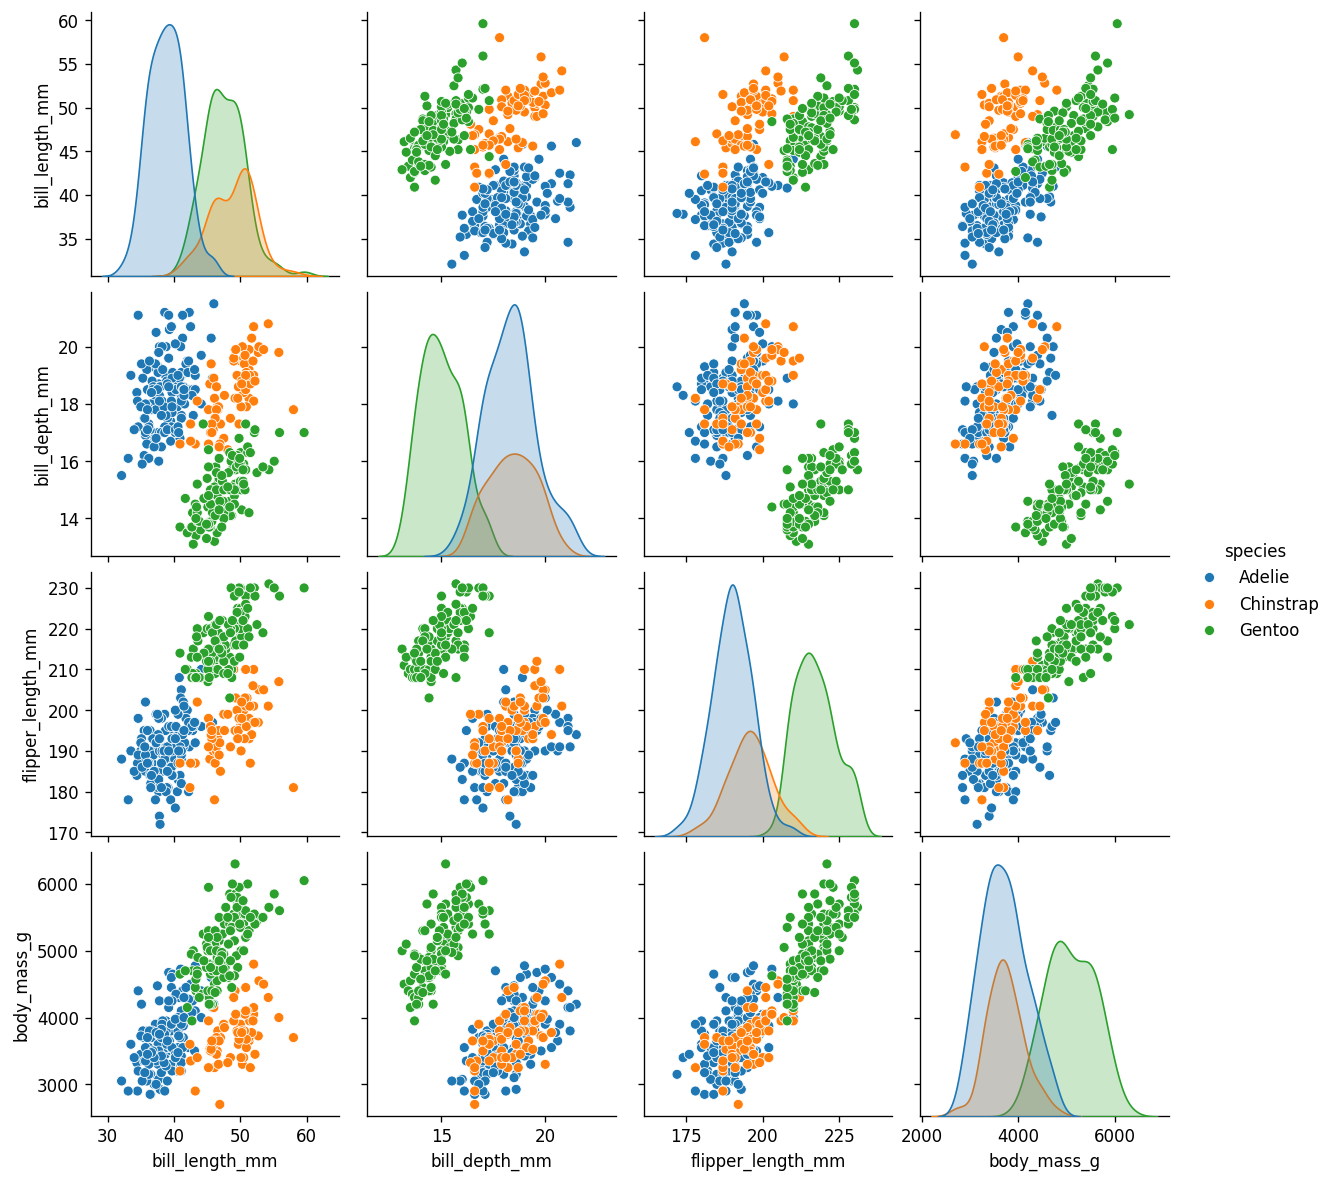

In [3]:
pairplot_figure = sns.pairplot(df, hue="species")

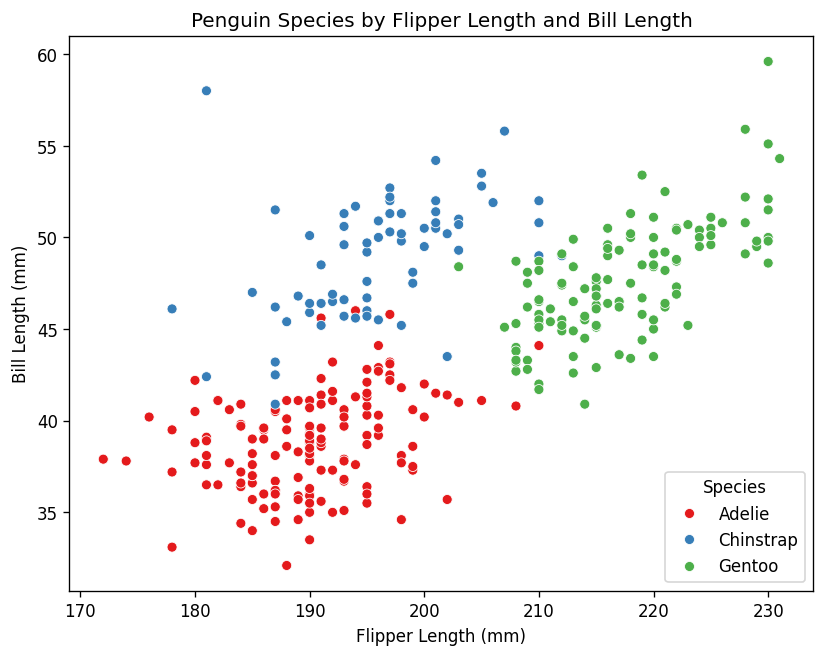

In [4]:
# Graficar los clusters usando matplotlib Flipper length vs. bill length
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='flipper_length_mm', y='bill_length_mm', hue='species', palette='Set1')
plt.title('Penguin Species by Flipper Length and Bill Length')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Bill Length (mm)')
plt.legend(title='Species')
plt.show()

## 2) Selección de variables y preprocesamiento

Usaremos variables numéricas típicas del dataset:

- `bill_length_mm`
- `bill_depth_mm`
- `flipper_length_mm`
- `body_mass_g`

Como K-Means usa distancias Euclidianas, el **escalado** es crítico (si no, variables con mayor rango dominan).  
También imputaremos valores faltantes con la **mediana**.


In [5]:
feature_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
#feature_cols = ["bill_depth_mm","flipper_length_mm"]
target_col = "species"  # se usa sólo para el mapeo post-hoc cluster->especie

work = df[feature_cols + [target_col]].copy()

# Pipeline de preprocesamiento
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_raw = work[feature_cols]
y = work[target_col]

X = preprocess.fit_transform(X_raw)
X.shape


(333, 4)

## 3) Determinar k con Elbow y Silueta

- **Elbow**: usa `inertia_` (SSE intra-cluster). Buscamos un “codo”: a partir de cierto k, la mejora marginal cae.
- **Silueta**: mide separación vs cohesión (rango -1 a 1). Mayor es mejor. Requiere k ≥ 2.


Mejor k según silhouette: 2 (score=0.5308)


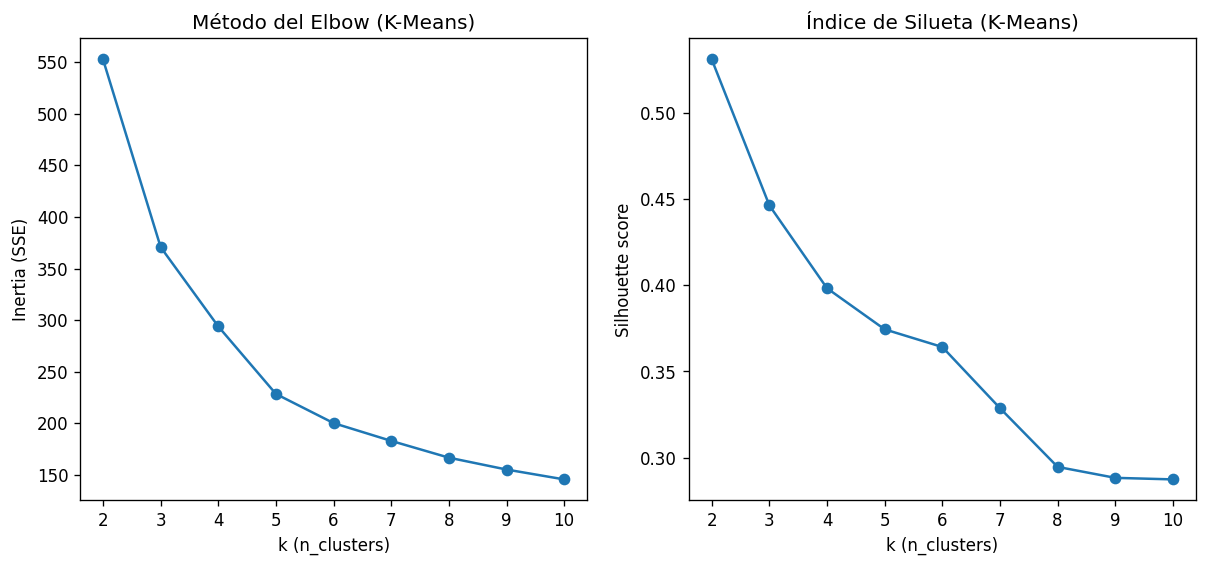

In [6]:
k_values = range(2, 11)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

best_k_sil = list(k_values)[int(np.argmax(sil_scores))]
print(f"Mejor k según silhouette: {best_k_sil} (score={max(sil_scores):.4f})")

# Gráficos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("k (n_clusters)")
plt.ylabel("Inertia (SSE)")
plt.title("Método del Elbow (K-Means)")

plt.subplot(1, 2, 2)
plt.plot(list(k_values), sil_scores, marker="o")
plt.xlabel("k (n_clusters)")
plt.ylabel("Silhouette score")
plt.title("Índice de Silueta (K-Means)")
plt.show()


## 4) Entrenar el K-Means final y revisar clusters

Tomaremos como `k_final` el mejor por silueta (se puede ajustar si el elbow sugiere otro valor razonable).


In [7]:
k_final = best_k_sil
k_final = 3  # Elegido tras inspección visual de gráficos
kmeans_final = KMeans(n_clusters=k_final, n_init=30, random_state=42)
cluster_labels = kmeans_final.fit_predict(X)

work["cluster"] = cluster_labels # cluster 0, 1 , 2

print("Distribución de clusters:")
display(work["cluster"].value_counts().sort_index())

# Tabla cruzada (especie vs cluster) para inspección
ct = pd.crosstab(work["cluster"], work[target_col], normalize="index")
ct


Distribución de clusters:


cluster
0    129
1    119
2     85
Name: count, dtype: int64

species,Adelie,Chinstrap,Gentoo
cluster,,,
0,0.961240,0.038760,0.0
1,0.000000,0.000000,1.0
2,0.258824,0.741176,0.0


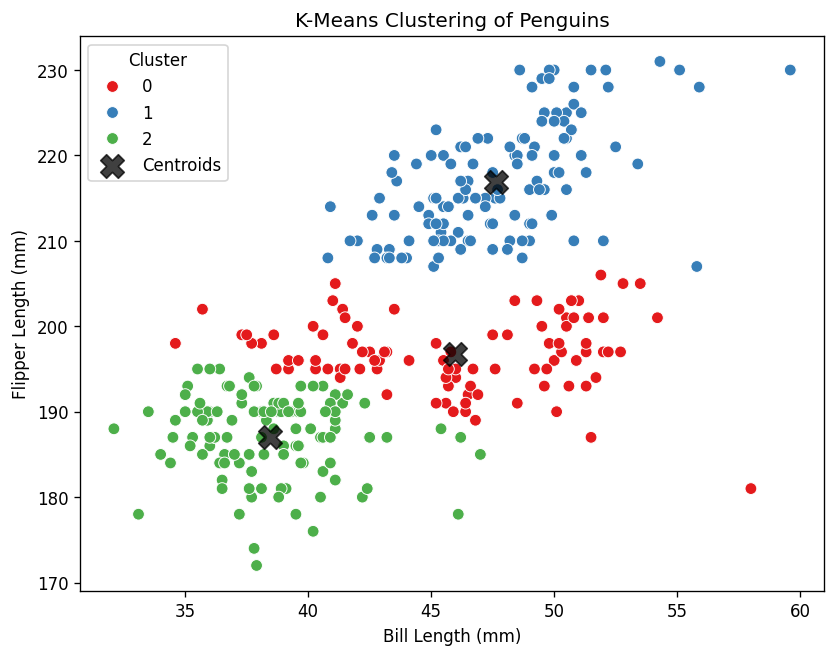

In [13]:
# Crear matriz de características (usamos bill_length_mm y bill_depth_mm)
X_penguins = df[["bill_length_mm", "flipper_length_mm"]].values

# Crear el modelo KMeans y ajustar/predicción
kmeans_penguins = KMeans(n_clusters=3, random_state=42)

# Crear un DataFrame temporal con los resultados de K-means
y_penguins = kmeans_penguins.fit_predict(X_penguins)
ers_penguins = kmeans_penguins.cluster_centers_

penguins_clustered = pd.DataFrame(X_penguins, columns=["bill_length_mm", "flipper_length_mm"])
penguins_clustered['cluster'] = y_penguins

# graficar los cluster usando seaborn
plt.figure(figsize=(8,6))
sns.scatterplot(data=penguins_clustered, x='bill_length_mm', y='flipper_length_mm', hue='cluster', 
                palette='Set1',
                s=50, legend='full')
plt.scatter(ers_penguins[:, 0], ers_penguins[:, 1], c='black', s=200, alpha=0.75, marker='X', label='Centroids')
plt.title('K-Means Clustering of Penguins')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.legend(title='Cluster')
plt.show()


## 6) “Predicción” de especie para datos nuevos

Como K-Means no es supervisado, haremos un mapeo **post-hoc**:

1. Para cada cluster, buscamos la **especie mayoritaria** observada en el dataset (`cluster_to_species`).
2. Para datos nuevos:
   - Preprocesamos con el mismo pipeline,
   - Asignamos cluster con `kmeans_final.predict`,
   - Devolvemos especie estimada y una distribución empírica `p_especie` según el cluster.

Esto sirve como baseline. Para clasificación real, preferir un modelo supervisado.


In [15]:
# Mapeo cluster -> especie por mayoría
cluster_to_species = (
    work.groupby("cluster")[target_col]
        .agg(lambda s: s.value_counts().idxmax())
        .to_dict()
)
print("Mapeo cluster -> especie (mayoría):")
cluster_to_species


Mapeo cluster -> especie (mayoría):


{0: 'Adelie', 1: 'Gentoo', 2: 'Chinstrap'}

In [16]:
# Distribución empírica de especies por cluster (para pseudo-probabilidades)
cluster_species_dist = (
    work.groupby("cluster")[target_col]
        .value_counts(normalize=True)
        .rename("p")
        .reset_index()
)

dist_dict = {}
for _, row in cluster_species_dist.iterrows():
    dist_dict.setdefault(int(row["cluster"]), {})[row[target_col]] = float(row["p"])

cluster_species_dist.sort_values(["cluster", "p"], ascending=[True, False]).head(10)


,cluster,species,p
0,0,Adelie,0.961240
1,0,Chinstrap,0.038760
2,1,Gentoo,1.000000
3,2,Chinstrap,0.741176
4,2,Adelie,0.258824


## Prediccion

In [17]:
def predict_especies(new_samples: pd.DataFrame) -> pd.DataFrame:
    """
    new_samples: DataFrame con columnas feature_cols.
    Retorna: cluster, especie_predicha (mayoría) y probs empíricas por especie.
    """
    # si falta un valor de las columnas esperadas, error
    missing = [c for c in feature_cols if c not in new_samples.columns]
    if missing:
        raise ValueError(f"Faltan columnas en new_samples: {missing}")
    # ---
    X_new = preprocess.transform(new_samples[feature_cols])
    cl_new = kmeans_final.predict(X_new)

    species_levels = sorted(work[target_col].dropna().unique())

    rows = []
    for cl in cl_new:
        cl = int(cl)
        probs = dist_dict.get(cl, {})
        rows.append({
            "cluster": cl,
            "species_pred": cluster_to_species.get(cl, "unknown"),
            **{f"p_{sp}": probs.get(sp, 0.0) for sp in species_levels}
        })

    return pd.concat([new_samples.reset_index(drop=True), pd.DataFrame(rows)], axis=1)

# Ejemplo con 3 pingüinos hipotéticos (datos nuevos)
new_data = pd.DataFrame({
    "bill_length_mm": [39.1, 48.7, 44.5],
    "bill_depth_mm": [18.7, 14.1, 17.2],
    "flipper_length_mm": [181, 214, 200],
    "body_mass_g": [3750, 5200, 4200]
})

preds = predict_especies(new_data)
preds


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,cluster,species_pred,p_Adelie,p_Chinstrap,p_Gentoo
0,39.1,18.7,181,3750,0,Adelie,0.961240,0.038760,0.0
1,48.7,14.1,214,5200,1,Gentoo,0.000000,0.000000,1.0
2,44.5,17.2,200,4200,2,Chinstrap,0.258824,0.741176,0.0


## 7) Interpretación

- Si `k` sale cercano a 3, suele alinearse con la idea de 3 especies principales en el dataset (aunque los clusters no siempre coinciden 1:1 con especie).
- Un **silhouette** más alto sugiere clusters más “compactos y separados”.
- Si la tabla cruzada `cluster vs species` muestra mezclas fuertes, significa que con estas variables no hay separación perfecta por especie (esperable en datos reales).
